In [1]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [6]:
# Constants
parent_folder  = "results-try"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["Epoch", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign"]
print("Found {} results".format(len(all_files)))

_DISCARD_ = True
_REPLACE_ = False

Found 0 results


In [7]:
print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['alpha'] = float(_params[3])
    _df['tolerance'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    # Local Processing
    if float(_params[4]) == 3.0 and float(_params[5]) <=3 and float(_params[3]) == 0.5:
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
print("We ended up with {} rows".format(len(df)))

Import results...


0it [00:00, ?it/s]


ValueError: No objects to concatenate

In [5]:
# Calculate Precision and Recall
print("Calculate precision and recall")
df['Recall'] = df.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df['Precision'] = df.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")


Calculate precision and recall
Recall done
Precision done


In [12]:
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df['Consensus Accuracy'] = df.apply(lambda row: ("Right" if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else "Wrong"), axis=1)
print("Consensus Accuracy done")

df_def = df

Consensus Accuracy done


In [13]:
# Reduce dataset for tests XXX
df_def = df.drop(df[df.repetition > 0].index)
df_def = df_def.drop(df_def[df_def.alpha == 0.3].index)
df_def

,Epoch,sources,malign,ban_sources,ban_malign,consensus,rep_benign,rep_malign,rep_min,ratio_malign,alpha,tolerance,repetition,Recall,Precision,Consensus Accuracy
170000,0,500,0,0,0,24.009769,0.009695,0.000000,-0.8,1.00,0.5,5.0,0.0,0.000000,0.0,1
170001,1,500,0,0,0,23.966536,0.018191,0.000000,-0.8,1.00,0.5,5.0,0.0,0.000000,0.0,1
170002,2,500,0,0,0,23.290903,0.026369,0.000000,-0.8,1.00,0.5,5.0,0.0,0.000000,0.0,1
170003,3,500,0,0,0,26.625295,0.035698,0.000000,-0.8,1.00,0.5,5.0,0.0,0.000000,0.0,1
170004,4,500,0,0,0,21.774601,0.042642,0.000000,-0.8,1.00,0.5,5.0,0.0,0.000000,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1599995,9995,1000,386,65,65,25.911620,0.863317,0.071764,-0.8,0.75,0.5,5.0,0.0,0.168394,1.0,1
1599996,9996,1000,386,65,65,20.623290,0.861979,0.074387,-0.8,0.75,0.5,5.0,0.0,0.168394,1.0,1
1599997,9997,1000,386,65,65,27.746367,0.861719,0.074387,-0.8,0.75,0.5,5.0,0.0,0.168394,1.0,1
1599998,9998,1000,386,65,65,26.631128,0.861803,0.073890,-0.8,0.75,0.5,5.0,0.0,0.168394,1.0,1


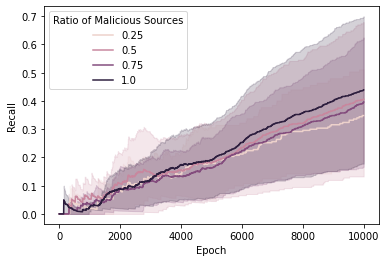

In [14]:
# PLOT 1 [ DISCARD PLOT ] - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "ratio of malignous sources" is the discriminant here
img_name = "num_mal_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='ratio_malign')
        plt.legend(title='Ratio of Malicious Sources', loc='upper left')
        plt.savefig(img_name, dpi=300)
        print (img_name + "Done")

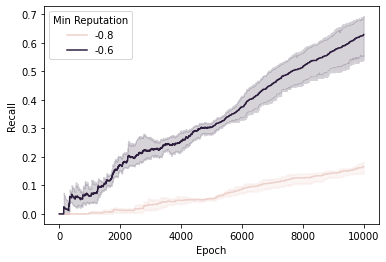

In [15]:
# PLOT 1 - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min')
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [7]:
# PLOT 1 [DISCARD PLOT] - PRECISION OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_prec_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min')
        plt.legend(title='Min Reputation', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

IndentationError: unexpected indent (731449446.py, line 5)

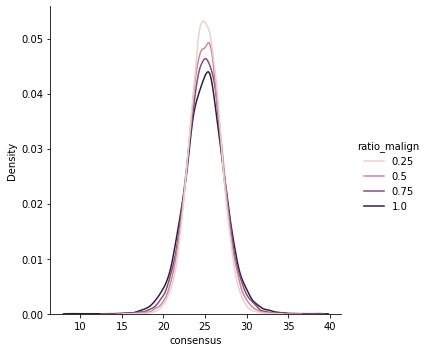

In [11]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_num_mal.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='ratio_malign', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

No handles with labels found to put in legend.


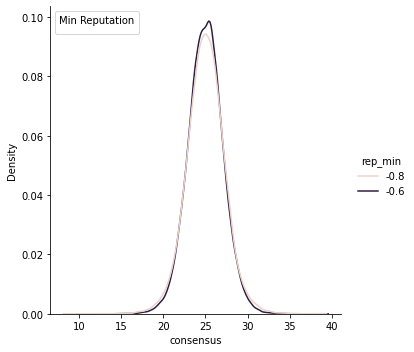

In [21]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_min_rep.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='rep_min', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

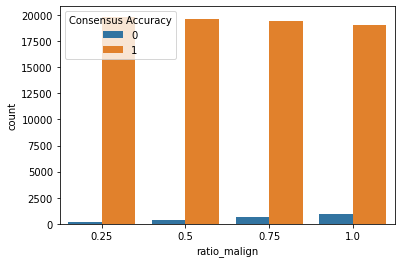

In [15]:
# PLOT 2 - IMPACT ON CONSENSUS ACCURACY

df_def['Consensus Accuracy'].value_counts()

# Comparison of this algo with another dummy one ? Only one bar !
# Average - no kick out
# Median - with ranking - no kick out

sns.countplot(data=df_def, x='ratio_malign', hue='Consensus Accuracy')
plt.show()


KeyboardInterrupt: 

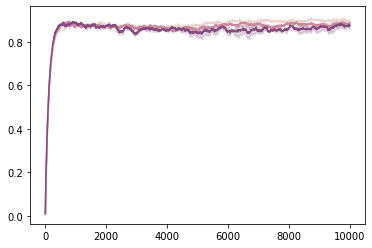

In [22]:
df_use = df_def
df_good = df_use.drop(df[df.repetition > 0].index)


# PLOT 1
sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign')
sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign')
plt.legend(title='Ratio malicious', loc='upper left')
#plt.savefig("min_rep_over_time.png", dpi=300)
plt.show()